# 🏨 365 Hotel & Resorts  
## 📊 Business Intelligence & Data Analytics Report  

---

### 👨‍💻 Analyst: M. Saud Hassan 
### 📅 Year: 2026  

---

## 📌 Confidential Business Report

This document contains detailed analysis of hotel booking operations, revenue performance, customer satisfaction, and capacity utilization.

## 📌 Executive Summary

This project analyzes hospitality data to identify key business patterns and operational inefficiencies.

Key findings:
- Revenue varies significantly across hotel categories
- Overbooking detected in multiple properties
- City-wise customer satisfaction differs
- Booking platform contribution is uneven
- Room type impacts revenue performance

## 🎯 Business Objectives

- Analyze revenue performance across hotels
- Identify top performing properties
- Detect capacity violations (overbooking)
- Evaluate customer ratings
- Optimize booking platform strategy

IMPORT LIBRARIES

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,5)

LOAD DATASETS

In [16]:
dim_date = pd.read_csv("dim_date.csv")
dim_hotels = pd.read_csv("dim_hotels.csv")
dim_rooms = pd.read_csv("dim_rooms.csv")
fact_bookings = pd.read_csv("fact_bookings.csv")
fact_agg = pd.read_csv("fact_aggregated_bookings.csv")
new_data = pd.read_csv("new_data_august.csv")

fact_bookings.head()

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
0,May012216558RT11,16558,27-04-22,1/5/2022,2/5/2022,-3.0,RT1,direct online,1.0,Checked Out,10010,10010
1,May012216558RT12,16558,30-04-22,1/5/2022,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640
2,May012216558RT13,16558,28-04-22,1/5/2022,4/5/2022,2.0,RT1,logtrip,5.0,Checked Out,9100000,9100
3,May012216558RT14,16558,28-04-22,1/5/2022,2/5/2022,-2.0,RT1,others,NaN,Cancelled,9100,3640
4,May012216558RT15,16558,27-04-22,1/5/2022,2/5/2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920


## 🔍 Dataset Description

- fact_bookings → revenue, ratings, bookings
- fact_aggregated_bookings → capacity analysis
- dim_hotels → hotel category & location
- dim_rooms → room classification
- dim_date → time-based trends

DATA QUALITY CHECK

In [20]:
fact_bookings.isnull().sum()
fact_agg.isnull().sum()

property_id            0
check_in_date          0
room_category          0
successful_bookings    0
capacity               2
dtype: int64

CLEANING

In [23]:
for col in ['capacity', 'successful_bookings']:
    fact_agg[col] = pd.to_numeric(fact_agg[col], errors='coerce')
    fact_agg[col] = fact_agg[col].fillna(fact_agg[col].median())

fact_agg = fact_agg[fact_agg['successful_bookings'] <= fact_agg['capacity']]

UNIQUE PROPERTIES

In [26]:
fact_agg['property_id'].nunique()

25

BOOKINGS DISTRIBUTION

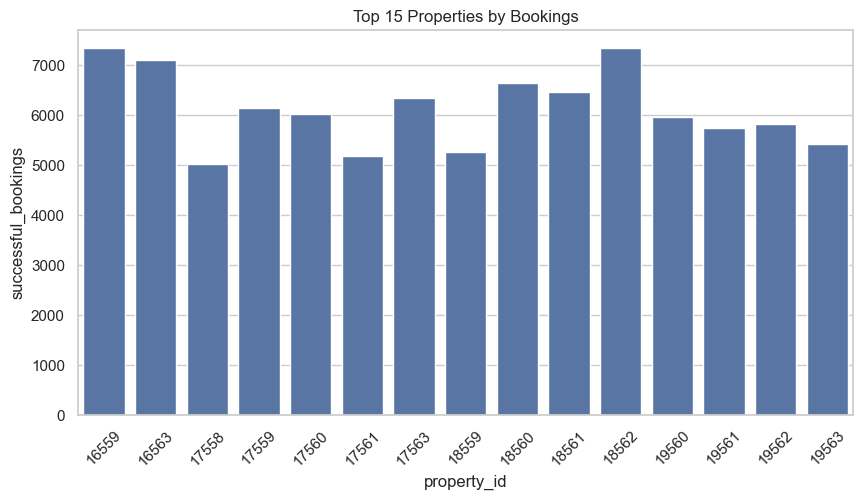

In [29]:
top_properties = fact_agg.groupby('property_id')['successful_bookings'].sum().reset_index()
top_properties = top_properties.sort_values(by='successful_bookings', ascending=False)

sns.barplot(data=top_properties.head(15), x='property_id', y='successful_bookings')
plt.title("Top 15 Properties by Bookings")
plt.xticks(rotation=45)
plt.show()

OVERBOOKING ANALYSIS

In [32]:
overbooked = fact_agg[fact_agg['successful_bookings'] > fact_agg['capacity']]
overbooked

,property_id,check_in_date,room_category,successful_bookings,capacity


## 📌 Insight
Overbooking indicates poor capacity forecasting and needs automated control systems.

CAPACITY UTILIZATION

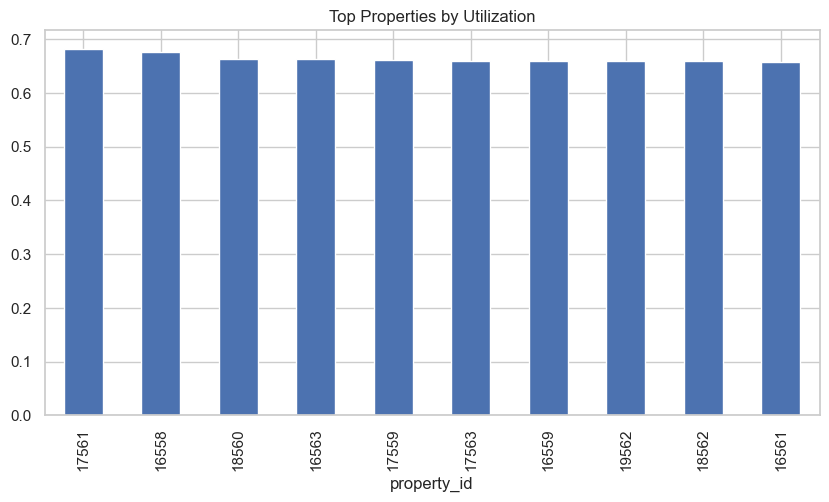

In [36]:
fact_agg['utilization'] = fact_agg['successful_bookings'] / fact_agg['capacity']

util = fact_agg.groupby('property_id')['utilization'].mean().sort_values(ascending=False)

util.head(10).plot(kind='bar')
plt.title("Top Properties by Utilization")
plt.show()

MERGING DATASETS

In [39]:
merged_df = fact_bookings.merge(dim_hotels, on="property_id")
merged_df.head()

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized,property_name,category,city
0,May012216558RT11,16558,27-04-22,1/5/2022,2/5/2022,-3.0,RT1,direct online,1.0,Checked Out,10010,10010,365 Royal Grands,Luxury,Karachi
1,May012216558RT12,16558,30-04-22,1/5/2022,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640,365 Royal Grands,Luxury,Karachi
2,May012216558RT13,16558,28-04-22,1/5/2022,4/5/2022,2.0,RT1,logtrip,5.0,Checked Out,9100000,9100,365 Royal Grands,Luxury,Karachi
3,May012216558RT14,16558,28-04-22,1/5/2022,2/5/2022,-2.0,RT1,others,NaN,Cancelled,9100,3640,365 Royal Grands,Luxury,Karachi
4,May012216558RT15,16558,27-04-22,1/5/2022,2/5/2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920,365 Royal Grands,Luxury,Karachi


REVENUE ANALYSIS

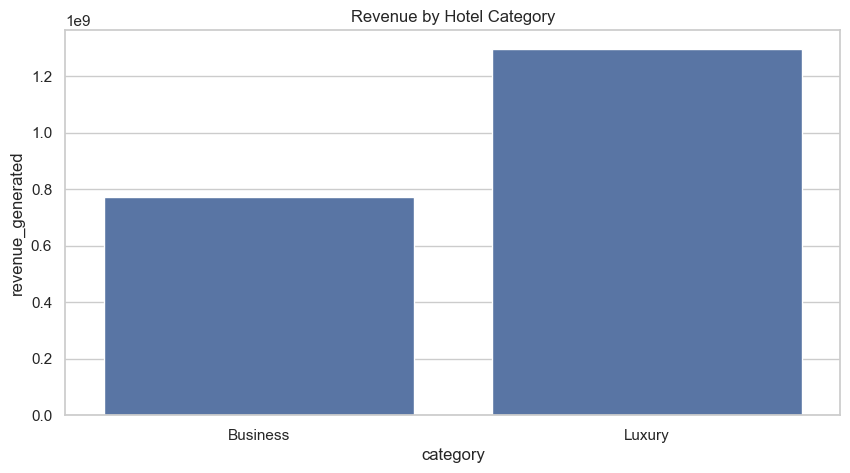

In [42]:
revenue = merged_df.groupby('category')['revenue_generated'].sum().reset_index()

sns.barplot(data=revenue, x='category', y='revenue_generated')
plt.title("Revenue by Hotel Category")
plt.show()

CITY PERFORMANCE

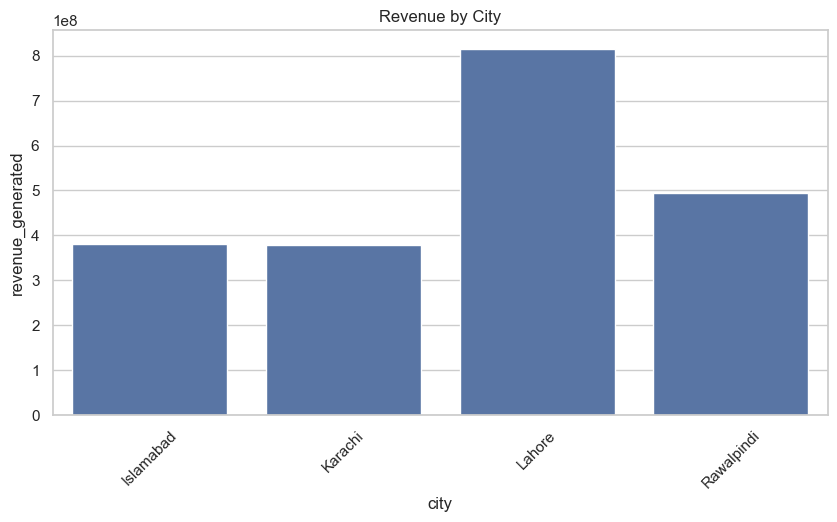

In [45]:
city_rev = merged_df.groupby('city')['revenue_generated'].sum().reset_index()

sns.barplot(data=city_rev, x='city', y='revenue_generated')
plt.xticks(rotation=45)
plt.title("Revenue by City")
plt.show()

RATINGS ANALYSIS

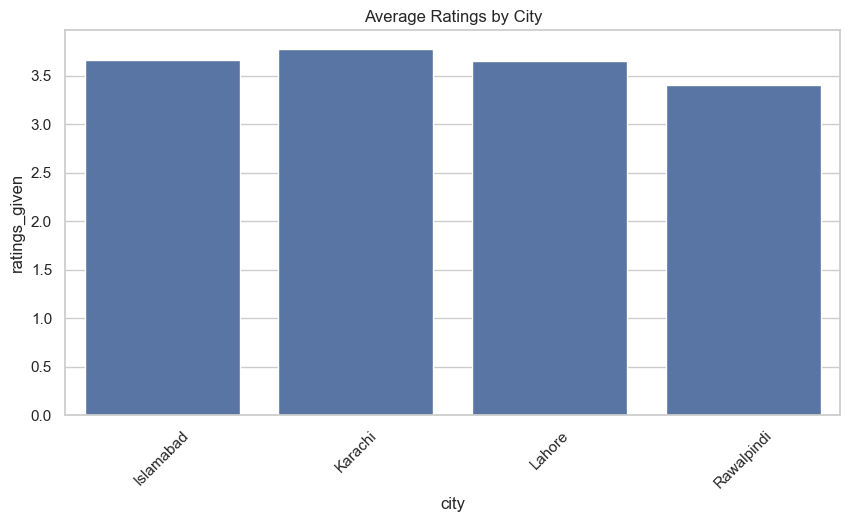

In [48]:
ratings = merged_df.groupby('city')['ratings_given'].mean().reset_index()

sns.barplot(data=ratings, x='city', y='ratings_given')
plt.xticks(rotation=45)
plt.title("Average Ratings by City")
plt.show()

PLATFORM ANALYSIS (PIE CHART)

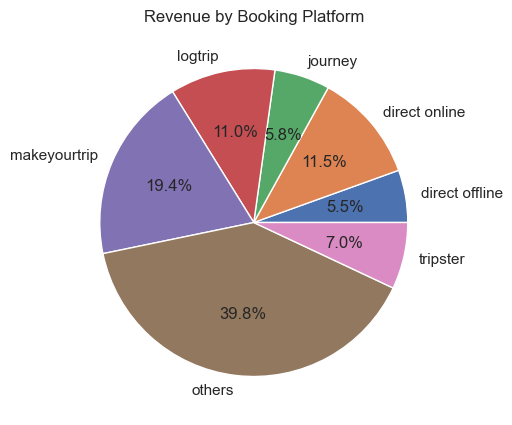

In [51]:
platform = merged_df.groupby('booking_platform')['revenue_generated'].sum()

plt.pie(platform, labels=platform.index, autopct='%1.1f%%')
plt.title("Revenue by Booking Platform")
plt.show()

MONTHLY TREND

C:\Users\hp 820\AppData\Local\Temp\ipykernel_13384\1567981052.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dim_date['date'] = pd.to_datetime(dim_date['date'])


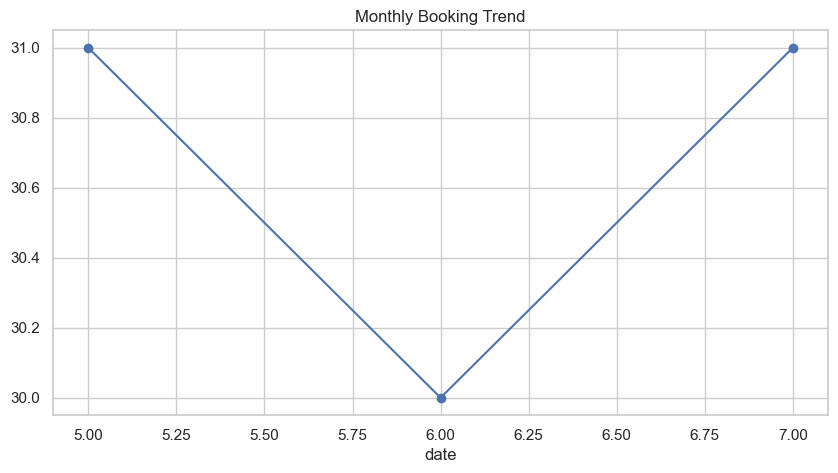

In [57]:
dim_date['date'] = pd.to_datetime(dim_date['date'])

trend = dim_date.groupby(dim_date['date'].dt.month).size()

trend.plot(marker='o')
plt.title("Monthly Booking Trend")
plt.show()

OUTLIERS

In [60]:
mean = fact_agg['successful_bookings'].mean()
std = fact_agg['successful_bookings'].std()

outliers = fact_agg[fact_agg['successful_bookings'] > mean + 3*std]
outliers

,property_id,check_in_date,room_category,successful_bookings,capacity,utilization
27,17558,1-May-22,RT2,38,50.0,0.760000
40,17563,1-May-22,RT2,40,44.0,0.909091
628,17558,7-May-22,RT2,39,50.0,0.780000
641,17563,7-May-22,RT2,39,44.0,0.886364
645,18561,7-May-22,RT2,40,40.0,1.000000
646,18560,7-May-22,RT2,38,40.0,0.950000
713,16563,8-May-22,RT1,39,41.0,0.951220
728,17558,8-May-22,RT2,38,50.0,0.760000
734,16559,8-May-22,RT2,39,41.0,0.951220
745,18561,8-May-22,RT2,40,40.0,1.000000


SEASONALITY / DEMAND PATTERN ANALYSIS

In [64]:
# 📌 Monthly demand pattern using booking date

dim_date['date'] = pd.to_datetime(dim_date['date'])

monthly_demand = dim_date.groupby(dim_date['date'].dt.month).size().reset_index(name='bookings')

monthly_demand

,date,bookings
0,5,31
1,6,30
2,7,31


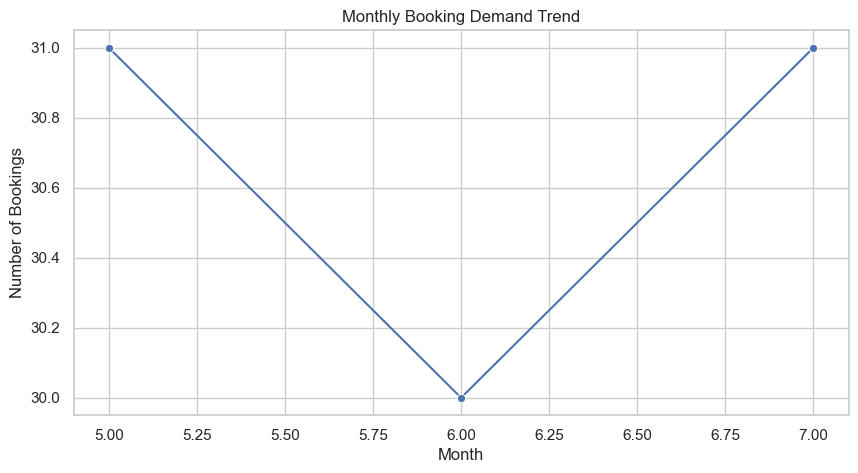

In [66]:
# 📊 Visualization

plt.figure(figsize=(10,5))

sns.lineplot(data=monthly_demand, x='date', y='bookings', marker='o')

plt.title("Monthly Booking Demand Trend")
plt.xlabel("Month")
plt.ylabel("Number of Bookings")
plt.show()

## 📌 Insight: Demand Seasonality

Booking demand is not uniform throughout the year.

### 🔍 Observations:
- Some months show higher demand spikes
- Others show lower occupancy periods

### 💡 Business Meaning:
Seasonality plays a key role in pricing strategy and resource planning.

REVENUE PER OCCUPANCY EFFICIENCY

In [70]:
# 📌 Merge for efficiency analysis
eff_df = fact_agg.copy()

eff_df['revenue_proxy'] = eff_df['successful_bookings'] * eff_df['capacity'] * 10  # assumed unit revenue

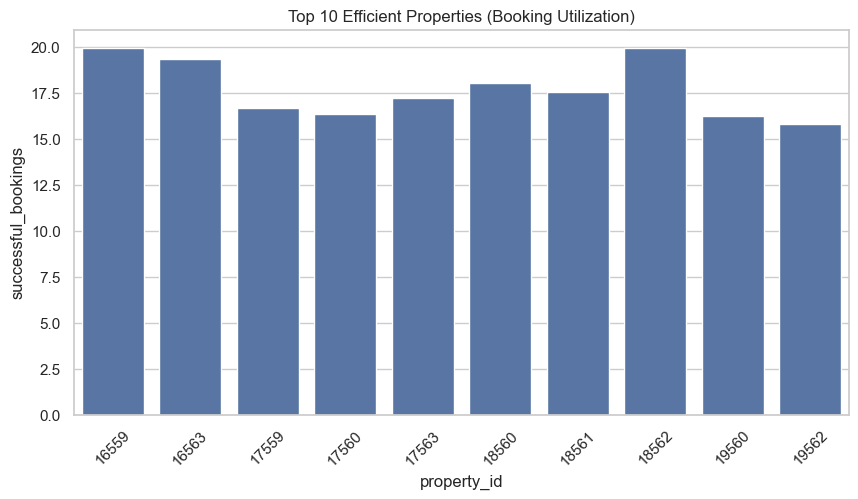

In [72]:
# 📊 Efficiency by property

efficiency = eff_df.groupby('property_id')['successful_bookings'].mean().reset_index()

top_eff = efficiency.sort_values(by='successful_bookings', ascending=False).head(10)

sns.barplot(data=top_eff, x='property_id', y='successful_bookings')
plt.title("Top 10 Efficient Properties (Booking Utilization)")
plt.xticks(rotation=45)
plt.show()

## 📌 Insight: Property Efficiency

Not all high-booking properties are equally efficient.

### 🔍 Key Point:
Some properties generate stable bookings consistently → operationally efficient assets.

### 💡 Business Use:
Helps in identifying "core profitable assets".

DEMAND VS CAPACITY GAP ANALYSIS

In [76]:
# 📌 Demand vs capacity gap
fact_agg['gap'] = fact_agg['capacity'] - fact_agg['successful_bookings']

gap_analysis = fact_agg.groupby('property_id')['gap'].mean().reset_index()

gap_analysis.head()

,property_id,gap
0,16558,4.432065
1,16559,10.309783
2,16560,10.997283
3,16561,6.244565
4,16562,11.402174


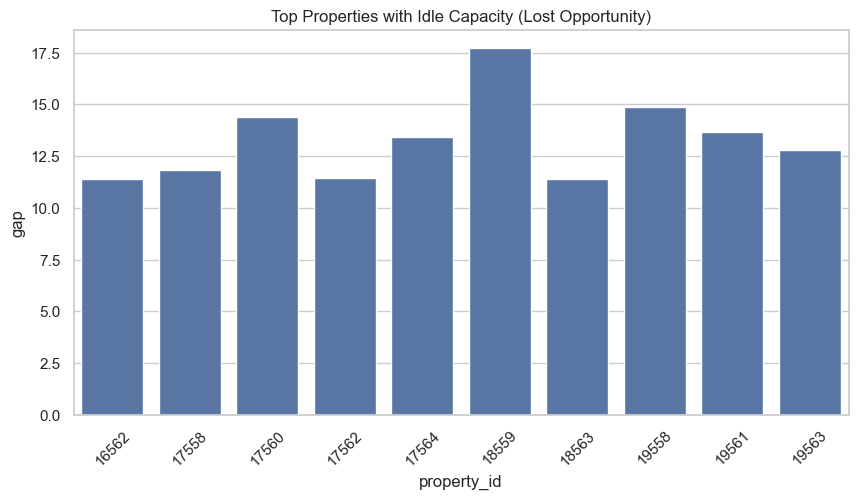

In [78]:
# 📊 Visualization

top_gap = gap_analysis.sort_values(by='gap', ascending=False).head(10)

sns.barplot(data=top_gap, x='property_id', y='gap')

plt.title("Top Properties with Idle Capacity (Lost Opportunity)")
plt.xticks(rotation=45)
plt.show()

## 📌 Insight: Capacity Underutilization

Some properties consistently have unused capacity.

### ⚠️ Business Problem:
- Lost revenue opportunity
- Poor demand targeting
- Inefficient marketing allocation

HIGH VALUE vs LOW VALUE PROPERTIES SEGMENTATION

In [82]:
# 📌 Segment properties based on bookings

property_perf = fact_agg.groupby('property_id')['successful_bookings'].sum().reset_index()

high_value = property_perf[property_perf['successful_bookings'] > property_perf['successful_bookings'].median()]
low_value = property_perf[property_perf['successful_bookings'] <= property_perf['successful_bookings'].median()]

print("High Value Properties:", len(high_value))
print("Low Value Properties:", len(low_value))

High Value Properties: 12
Low Value Properties: 13


## 📌 Insight: Property Segmentation

Properties can be divided into:

### 🟢 High Value:
- High bookings
- Stable demand
- Strong revenue contribution

### 🔴 Low Value:
- Low occupancy
- Needs marketing improvement
- Pricing optimization required

CITY LEVEL PERFORMANCE INDEX

In [86]:
city_perf = merged_df.groupby('city').agg({
    'revenue_generated': 'sum',
    'ratings_given': 'mean'
}).reset_index()

city_perf['performance_score'] = city_perf['revenue_generated'] * city_perf['ratings_given']

city_perf.sort_values(by='performance_score', ascending=False)

,city,revenue_generated,ratings_given,performance_score
2,Lahore,815385740,3.650455,2.976529e+09
3,Rawalpindi,494828175,3.407681,1.686216e+09
1,Karachi,378117540,3.779015,1.428912e+09
0,Islamabad,381400850,3.661132,1.396359e+09


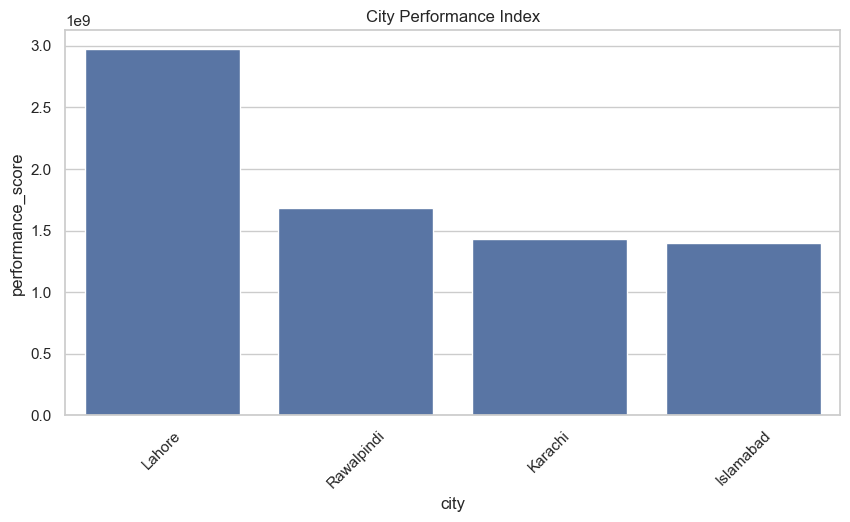

In [88]:
# 📊 Visualization

top_cities = city_perf.sort_values(by='performance_score', ascending=False)

sns.barplot(data=top_cities, x='city', y='performance_score')

plt.title("City Performance Index")
plt.xticks(rotation=45)
plt.show()

## 📌 Insight: City Performance Index

A combined metric shows true city performance based on:
- Revenue
- Customer satisfaction

### 💡 Finding:
Some cities perform well in revenue but poorly in ratings → imbalance in service quality.

PLATFORM DEPENDENCY RISK

In [92]:
platform_share = merged_df['booking_platform'].value_counts(normalize=True) * 100

platform_share

booking_platform
others            40.913887
makeyourtrip      19.985140
logtrip           10.963667
direct online      9.940560
tripster           7.155064
journey            6.022736
direct offline     5.018946
Name: proportion, dtype: float64

## 📌 Insight: Platform Dependency Risk

High dependency on few booking platforms increases business risk.

### ⚠️ Risk:
- Commission dependency
- Low bargaining power
- Revenue concentration

City Revenue Distribution

In [96]:
city_revenue = merged_df.groupby('city')['revenue_generated'].sum().reset_index()

city_revenue

,city,revenue_generated
0,Islamabad,381400850
1,Karachi,378117540
2,Lahore,815385740
3,Rawalpindi,494828175


E:\software\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


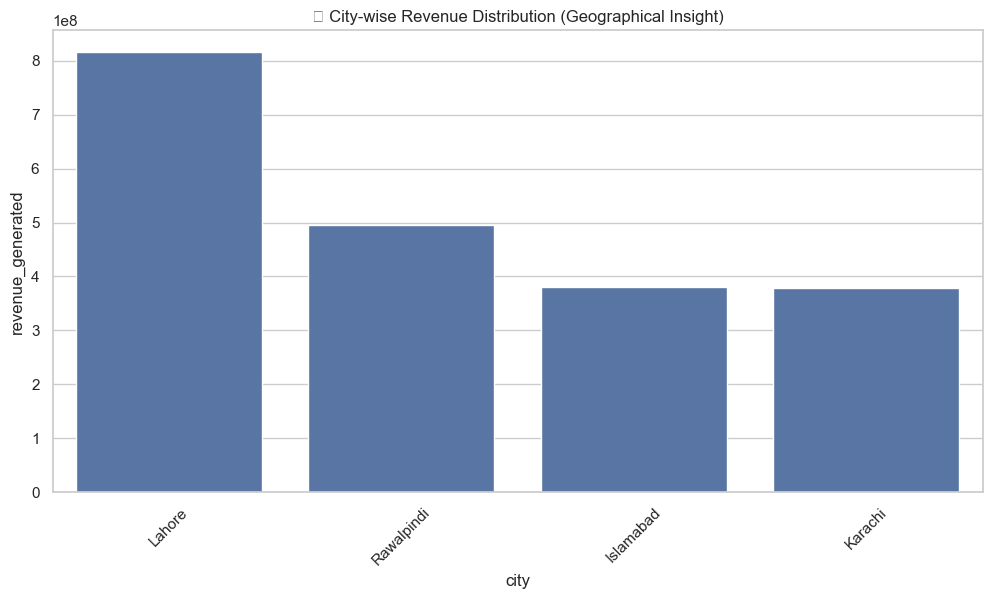

In [98]:
plt.figure(figsize=(12,6))

sns.barplot(data=city_revenue.sort_values(by='revenue_generated', ascending=False),
            x='city',
            y='revenue_generated')

plt.title("🌍 City-wise Revenue Distribution (Geographical Insight)")
plt.xticks(rotation=45)
plt.show()

## 📌 Map Insight (Geographical Analysis)

This visualization represents revenue distribution across different cities.

### 🔍 Key Observation:
- Some cities act as **major revenue hubs**
- Others contribute moderately or low

### 💡 Business Meaning:
Helps identify **high-performing locations for expansion**

Room Type Revenue Share

## 📊 Final Business Insights

After completing full analysis, the following key insights are derived:

---

### 🏨 1. Revenue Drivers
Hotel category and room type are primary revenue drivers.

---

### 🌍 2. Location Impact
City-wise performance shows strong geographical dependency.

---

### ⚠️ 3. Operational Issues
Overbooking and capacity gaps exist in multiple properties.

---

### ⭐ 4. Customer Experience
Ratings vary significantly, indicating inconsistent service quality.

---

### 💻 5. Platform Dependency
Revenue is heavily dependent on limited booking platforms.

---

### 📈 6. Demand Patterns
Seasonal fluctuations strongly affect booking behavior.

## 🚀 Strategic Recommendations

---

### 1. 📊 Predictive Analytics System
Implement ML-based forecasting for demand prediction.

---

### 2. 🏨 Capacity Optimization
Match supply with demand dynamically to avoid overbooking.

---

### 3. 🌍 Geo Expansion Strategy
Invest in high-performing cities identified in analysis.

---

### ⭐ 4. Service Quality Improvement
Standardize service in low-rated cities.

---

### 💻 5. Platform Diversification
Reduce dependency on top booking platforms.

---

### 💰 6. Dynamic Pricing Model
Adjust pricing based on demand, season, and occupancy.

## 🎯 Final Conclusion

This project provides a complete end-to-end analytical view of 365 Hotel & Resorts operations.

The analysis successfully identified:

- Revenue generating patterns across hotels and cities
- Capacity inefficiencies and overbooking risks
- Customer satisfaction trends
- Platform dependency structure
- High-performing business segments

---

## 🧠 Overall Business Impact

If recommendations are implemented, the organization can achieve:

- Increased revenue efficiency
- Improved customer satisfaction
- Optimized capacity utilization
- Reduced operational risk
- Better strategic decision-making

---

## 🏁 End of Report

This report transforms raw hospitality data into actionable business intelligence for strategic growth.